<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Visual-Recognition/blob/master/LAB_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Neural Style Transfer
*Based on a [PyTorch tutorial](https://docs.pytorch.org/tutorials/advanced/neural_style_tutorial.html) by Alexis Jacq and Winston Herring.*

This is a technique introduced in [A Neural Algorithm of Artistic Style](https://arxiv.org/abs/1508.06576) by Gatys, Ecker, and Bethge.

The goal is to generate a new image by combining two sources:

- a **content image**, which provides the objects and spatial structure,
- a **style image**, which provides colors, textures, and artistic patterns.

<img src="https://pytorch.org/tutorials/_static/img/neural-style/neuralstyle.png" alt="Neural Style Transfer" height="200"/>

The method assumes a pre-trained neural network and uses it as a feature extractor.
We start from an input image (usually a copy of the content image) and gradually update its pixels tominimize (a weighted sum of) two losses:
- **content similarity**: MSE between the features of the generated image and the content image,
- **style similarity**: MSE between the Gram matrices of the features of the generated image and the style image.

For a feature map $F$ of $(C, H, W)$, we think of it as $C$ vectors of length $H\cdot W$.
The Gram matrix is a $C \times C$ matrix of inner products between the features (channels):

$$ G = F F^T $$

**Question**: How to interpret it? Why does this work?<br>

## Imports

In [1]:
import time
from functools import partial
from pathlib import Path
from typing import Sequence

import ipywidgets
import matplotlib.pyplot as plt
import PIL.Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models
from torchvision.transforms import v2

device = torch.accelerator.current_accelerator(True) or torch.device("cpu")
print(device)
torch.set_default_device(device)

cuda


## Images
Add any images you want to IMG_DIR.

In [2]:
!mkdir -p data/style_transfer/contents/
!mkdir -p data/style_transfer/styles/
!wget -q https://mimuw.edu.pl/~mwrochna/upload/style_transfer/contents/cat.png -O data/style_transfer/contents/cat.png
!wget -q https://mimuw.edu.pl/~mwrochna/upload/style_transfer/contents/dancing.jpg -O data/style_transfer/contents/dancing.jpg
!wget -q https://mimuw.edu.pl/~mwrochna/upload/style_transfer/styles/greatwave.png -O data/style_transfer/styles/greatwave.png
!wget -q https://mimuw.edu.pl/~mwrochna/upload/style_transfer/styles/picasso.jpg -O data/style_transfer/styles/picasso.jpg

In [3]:
IMG_DIR = Path("data/style_transfer")

In [4]:
content_images = [
    PIL.Image.open(p).convert("RGB") for p in (IMG_DIR / "contents").iterdir() if p.suffix in {".jpg", ".png"}
]
style_images = [
    PIL.Image.open(p).convert("RGB") for p in (IMG_DIR / "styles").iterdir() if p.suffix in {".jpg", ".png"}
]

In [5]:
orig_transform = torchvision.models.VGG19_Weights.DEFAULT.transforms()
mean, std = orig_transform.mean, orig_transform.std  # ImageNet mean and std
mins, maxs = (
    [-m / s for m, s in zip(mean, std)],
    [(1 - m) / s for m, s in zip(mean, std)],
)

transform = v2.Compose(
    [
        v2.ToImage(),
        v2.Resize(256),
        v2.CenterCrop((224, 224)),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=mean, std=std),
    ]
)

untransform = v2.Compose(
    [
        v2.Normalize([-m / s for m, s in zip(mean, std)], [1 / s for s in std]),
        v2.ToDtype(torch.uint8, scale=True),
        v2.ToPILImage(),
    ]
)

In [6]:
content_batch = torch.stack([transform(img) for img in content_images])
style_batch = torch.stack([transform(img) for img in style_images])

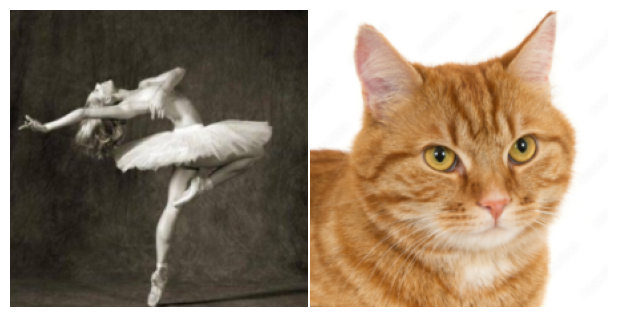

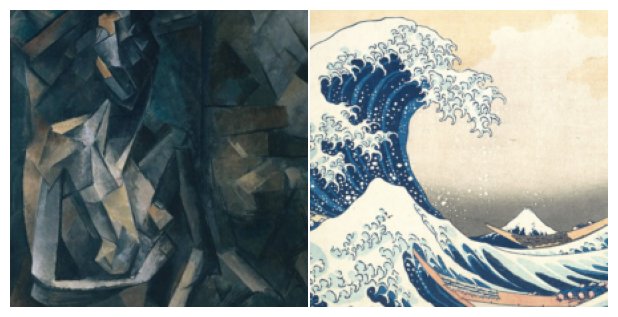

In [7]:
def show_image_row(images: Sequence[PIL.Image.Image], scale: int = 3) -> None:
    fig, axs = plt.subplots(
        nrows=1, ncols=len(images), figsize=(len(images) * scale, scale)
    )
    if len(images) == 1:
        axs = [axs]
    fig.set_layout_engine("constrained", h_pad=0, w_pad=0.01, hspace=0, wspace=0.01)
    for img, ax in zip(images, axs):
        ax.imshow(img)
        ax.axis("off")
    plt.show()


show_image_row([untransform(img) for img in content_batch])
show_image_row([untransform(img) for img in style_batch])

## Model

In [8]:
model = torchvision.models.vgg19(weights=torchvision.models.VGG19_Weights.DEFAULT)
model

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 101MB/s] 


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [9]:
model.get_submodule("features.2")

Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

## Grab features with hooks
`torch.Module`s can be hooked to run custom code during forward and backward passes: we'll use [register_module_forward_hook](https://docs.pytorch.org/docs/2.12/generated/torch.nn.modules.module.register_module_forward_hook.html).

In [10]:
def grab_features(
    x: torch.Tensor, model: nn.Module, layer_names: Sequence[str]
) -> dict[str, torch.Tensor]:
    """Run forward pass of `model` on `x` and return outputs of the submodules in `layer_names`."""
    features = {}

    def hook_set_features(name, _submodule, _input, output) -> None:
        features[name] = output
        if len(features) == len(layer_names):
            raise StopIteration

    hooks = []
    for layer_name in layer_names:
        layer = model.get_submodule(layer_name)
        hooks.append(
            layer.register_forward_hook(partial(hook_set_features, layer_name))
        )

    try:
        model(x)
    except StopIteration:
        pass

    for hook in hooks:
        hook.remove()

    assert set(features.keys()) == set(layer_names), (
        f"Expected features for layers {layer_names}, got {features.keys()}"
    )

    return features

In [11]:
with torch.no_grad():
    features = grab_features(style_batch, model, ["features.0", "features.2"]).items()
    print({name: f.shape for name, f in features})

{'features.0': torch.Size([2, 64, 224, 224]), 'features.2': torch.Size([2, 64, 224, 224])}


## Style transfer

In [20]:
def normed_gram_matrix(features: torch.Tensor) -> torch.Tensor:
    """
    Given a batch of feature maps, shape (B, C, H, W), return the gram matrices, shape (B, C, C).

    The result is 'normalized' by the number of elements in each feature map in the batch.
    """
    B, C, H, W = features.shape
    # Reshape to (B, C, H*W)
    x = features.view(B, C, H * W)
    # Batch matrix multiplication: (B, C, N) @ (B, N, C) -> (B, C, C)
    gram = torch.bmm(x, x.transpose(1, 2))
    return gram / (C * H * W)

In [13]:
def compute_losses(
    model: nn.Module,
    target_content_features: dict[str, torch.Tensor],
    target_style_grams: dict[str, torch.Tensor],
    input_img: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    content_layers = list(target_content_features.keys())
    style_layers = list(target_style_grams.keys())
    # TODO { features = …
    features = grab_features(input_img, model, set(content_layers + style_layers))
    #}

    content_loss = torch.tensor(0.0, device=device)
    for layer in content_layers:
        content_loss += F.mse_loss(features[layer], target_content_features[layer])

    style_loss = torch.tensor(0.0, device=device)
    for layer in style_layers:
        style_loss += F.mse_loss(
            normed_gram_matrix(features[layer]), target_style_grams[layer]
        )

    return content_loss, style_loss

In [21]:
def run_style_transfer(
    content_batch: torch.Tensor,
    style_batch: torch.Tensor,
    model: nn.Module,
    content_layers: Sequence[str],
    style_layers: Sequence[str],
    num_steps: int = 200,
    style_weight: float = 2.0e6,
    content_weight: float = 1.0,
    random_start: bool = False,
) -> list[PIL.Image.Image]:
    """
    Do neural style transfer turning each image in `content_batch` into the style of the corresponding image in `style_batch`.
    """
    B, C, H, W = content_batch.shape
    assert style_batch.shape == content_batch.shape

    model.eval()
    model.requires_grad_(False)

    with torch.no_grad():
        target_content_features = grab_features(content_batch, model, content_layers)
        style_features_dict = grab_features(style_batch, model, style_layers)
        target_style_grams = {name: normed_gram_matrix(f) for name, f in style_features_dict.items()}

    if random_start:
        image_batch = torch.rand_like(content_batch)
    else:
        image_batch = content_batch.clone()

    image_batch.requires_grad_(True)
    optimizer = optim.AdamW([image_batch], lr=0.02)

    # Visualization setup.
    last_time = 0
    text_output, img_output = ipywidgets.Output(), ipywidgets.Output()
    progress = ipywidgets.IntProgress(min=0, max=num_steps, description="Optimizing:")
    display(ipywidgets.VBox([ipywidgets.HBox([progress, text_output]), img_output]))

    # Main optimization loop.
    for i in range(num_steps):
        optimizer.zero_grad()
        content_loss, style_loss = compute_losses(
            model, target_content_features, target_style_grams, image_batch
        )
        loss = content_weight * content_loss + style_weight * style_loss
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            for c in range(C):
                image_batch[:, c].clamp_(mins[c], maxs[c])

        progress.value = i + 1
        now = time.time()
        if now - last_time > 2:
            last_time = now
            text_output.clear_output(wait=True)
            img_output.clear_output(wait=True)
            with text_output:
                print(
                    f"Step {i + 1}/{num_steps} ({((i + 1) / num_steps):.1%}), losses: "
                    f"content={content_loss.item():.4g}, "
                    f"style={style_loss.item():.4g}, "
                    f"total={loss.item():.4g}"
                )
            with img_output:
                show_image_row([untransform(img) for img in image_batch], scale=4)

    return [untransform(img) for img in image_batch]

You should already see some patterns after 5 steps.
100 steps should take ~8 min on Colab CPU and only ~10 s on T4 GPU.

In [ ]:
result = run_style_transfer(
    content_batch.repeat_interleave(len(style_batch), dim=0),
    style_batch.repeat(len(content_batch), 1, 1, 1),
    model=torchvision.models.vgg19(weights=torchvision.models.VGG19_Weights.DEFAULT),
    content_layers=("features.7",),
    style_layers=(
        "features.0",
        "features.2",
        "features.5",
        "features.7",
        "features.10",
    ),
    num_steps=200,
    style_weight=2.0e6,
    # random_start=True
)

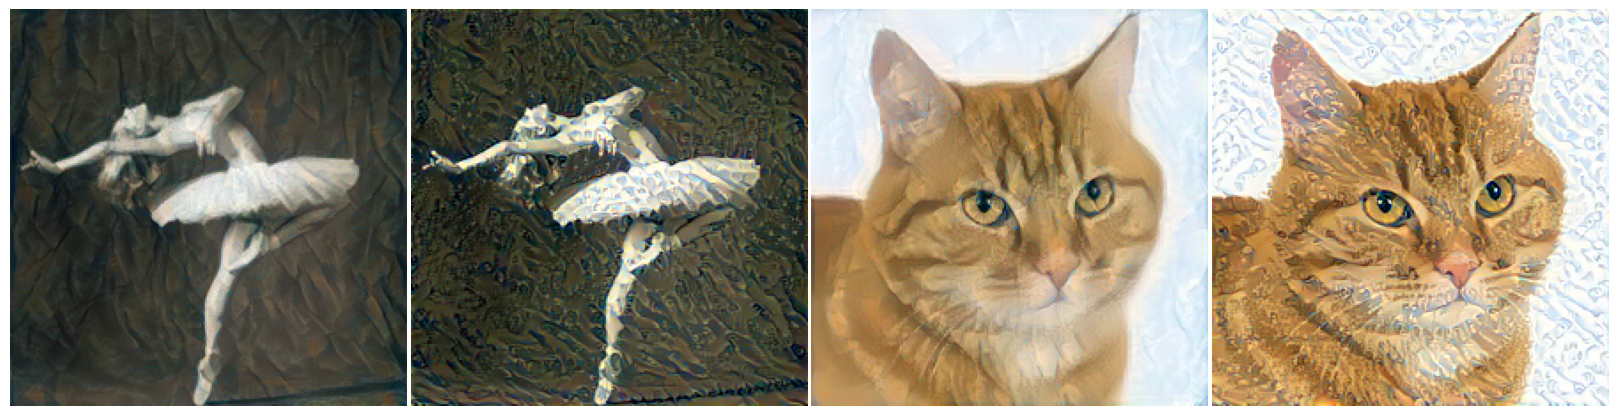

In [23]:
show_image_row(result, scale=4)

## Student tasks
* try different values of `style_weight` (note that also all the other changes may work better with different `style_weight` values).
* try choosing different layers (e.g. a single style layer at a time).
* try starting from noise instead of the content image.
* try a different model.
